In [1]:
pip install qiskit qiskit-aer

  Using cached rustworkx-0.18.0-cp310-abi3-win_amd64.whl.metadata (10 kB)
  Using cached stevedore-5.9.0-py3-none-any.whl.metadata (2.3 kB)
   ---------------------------------------- 0.0/9.4 MB ? eta -:--:--
   --------- ------------------------------ 2.4/9.4 MB 19.2 MB/s eta 0:00:01
   ------------------------- -------------- 6.0/9.4 MB 18.5 MB/s eta 0:00:01
   ----------------------------------- ---- 8.4/9.4 MB 15.3 MB/s eta 0:00:01
   ---------------------------------------- 9.4/9.4 MB 15.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   --------- ------------------------------ 2.4/9.6 MB 13.4 MB/s eta 0:00:01
   ------------------- -------------------- 4.7/9.6 MB 11.9 MB/s eta 0:00:01
   ------------------------------------- -- 8.9/9.6 MB 14.9 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 14.2 MB/s eta 0:00:00
Using cached rustworkx-0.18.0-cp310-abi3-win_amd64.whl (2.3 MB)
Using cached stevedore-5.9.0-py3-none-any.


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


X_train: (154, 2)
X_test:  (39, 2)


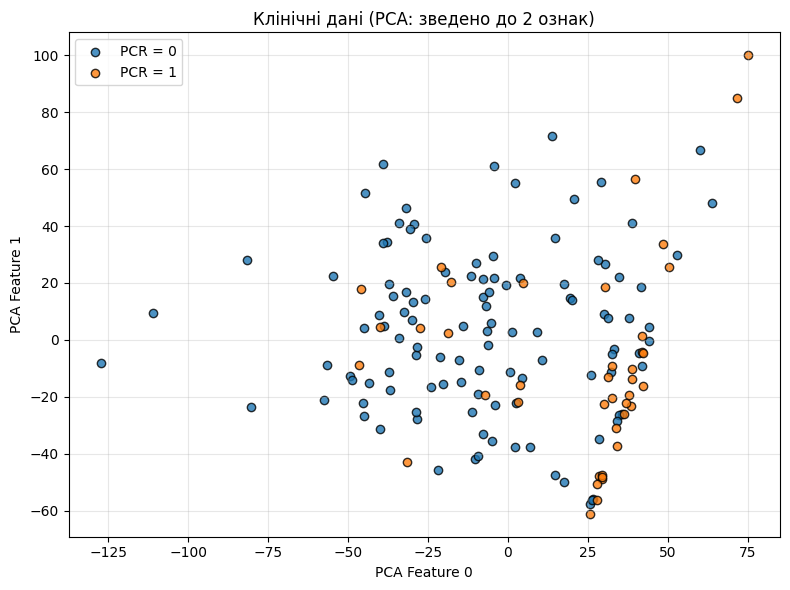

Number of qubits: 2
Number of trainable parameters: 24
     ┌──────────┐┌──────────┐┌──────────────┐┌──────────────┐┌──────────────┐»
q_0: ┤ Ry(x[0]) ├┤ Rz(x[1]) ├┤ Rx(theta[0]) ├┤ Ry(theta[1]) ├┤ Rz(theta[2]) ├»
     ├──────────┤├──────────┤├──────────────┤├──────────────┤├──────────────┤»
q_1: ┤ Ry(x[1]) ├┤ Rz(x[0]) ├┤ Rx(theta[3]) ├┤ Ry(theta[4]) ├┤ Rz(theta[5]) ├»
     └──────────┘└──────────┘└──────────────┘└──────────────┘└──────────────┘»
«          ┌──────────┐┌──────────┐┌──────────────┐ ┌──────────────┐»
«q_0: ──■──┤ Ry(x[0]) ├┤ Rz(x[1]) ├┤ Rx(theta[6]) ├─┤ Ry(theta[7]) ├»
«     ┌─┴─┐├──────────┤├──────────┤├──────────────┤┌┴──────────────┤»
«q_1: ┤ X ├┤ Ry(x[1]) ├┤ Rz(x[0]) ├┤ Rx(theta[9]) ├┤ Ry(theta[10]) ├»
«     └───┘└──────────┘└──────────┘└──────────────┘└───────────────┘»
«      ┌──────────────┐     ┌──────────┐┌──────────┐┌───────────────┐»
«q_0: ─┤ Rz(theta[8]) ├──■──┤ Ry(x[0]) ├┤ Rz(x[1]) ├┤ Rx(theta[12]) ├»
«     ┌┴──────────────┤┌─┴─┐├──────────┤├──────────┤├─────

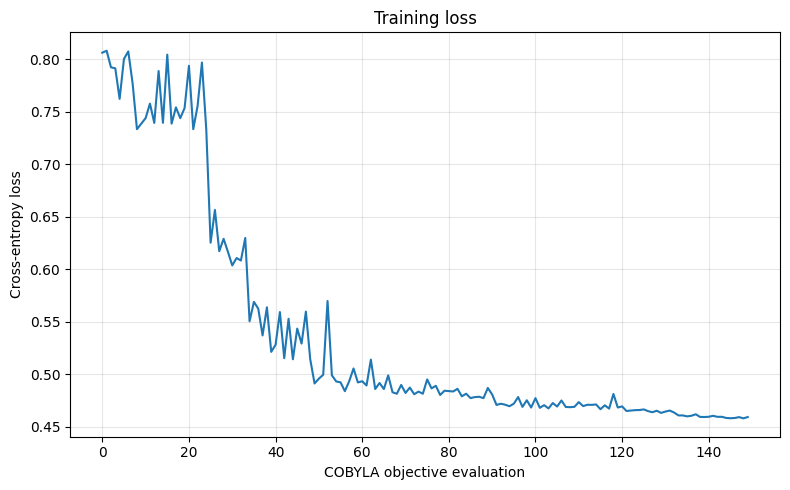

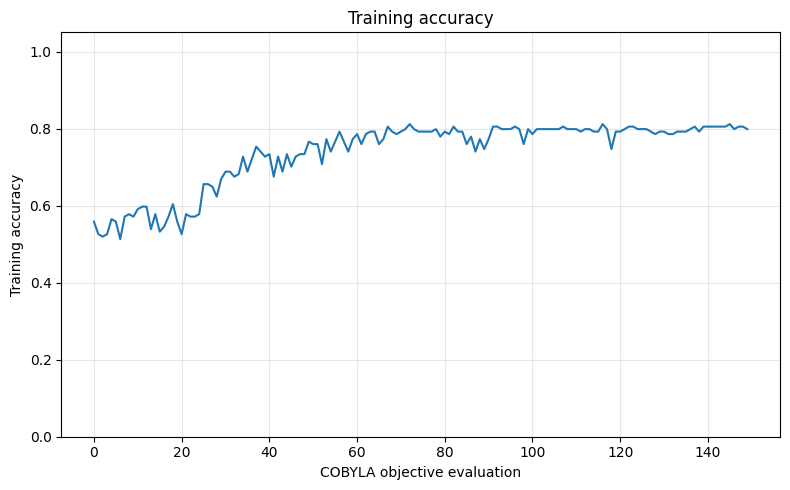

Final train accuracy: 81.17%
Final test accuracy:  66.67%

Test predictions:
expected=1 | P(class 0)=0.3223 | P(class 1)=0.6777 | predicted=1
expected=0 | P(class 0)=0.8223 | P(class 1)=0.1777 | predicted=0
expected=0 | P(class 0)=0.7227 | P(class 1)=0.2773 | predicted=0
expected=0 | P(class 0)=0.3496 | P(class 1)=0.6504 | predicted=1
expected=1 | P(class 0)=0.7578 | P(class 1)=0.2422 | predicted=0
expected=0 | P(class 0)=0.8086 | P(class 1)=0.1914 | predicted=0
expected=0 | P(class 0)=0.6719 | P(class 1)=0.3281 | predicted=0
expected=0 | P(class 0)=0.4102 | P(class 1)=0.5898 | predicted=1
expected=0 | P(class 0)=0.9746 | P(class 1)=0.0254 | predicted=0
expected=0 | P(class 0)=0.4980 | P(class 1)=0.5020 | predicted=1
expected=0 | P(class 0)=0.8457 | P(class 1)=0.1543 | predicted=0
expected=0 | P(class 0)=0.3164 | P(class 1)=0.6836 | predicted=1
expected=0 | P(class 0)=0.8809 | P(class 1)=0.1191 | predicted=0
expected=0 | P(class 0)=0.8633 | P(class 1)=0.1367 | predicted=0
expected=0 | 

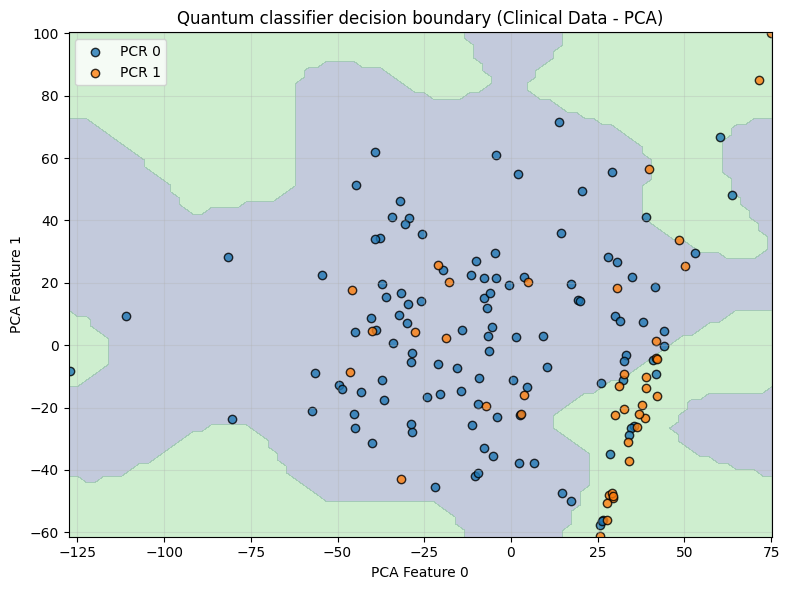

In [2]:
# In Colab, run:
# !pip install -q qiskit qiskit-aer scipy scikit-learn matplotlib

import matplotlib.pyplot as plt
import numpy as np
#added new imports
import pandas as pd
from sklearn.decomposition import PCA

from scipy.optimize import minimize
from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

from qiskit import QuantumCircuit, transpile
from qiskit.circuit import ParameterVector
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2


SEED = 42
NUM_QUBITS = 2
NUM_LAYERS = 4
READOUT_QUBIT = 1

NUM_SAMPLES = 150
NOISE = 0.12

# Exact probabilities make optimization much faster and less noisy.
# Set to an integer such as 512 to train with finite shots instead.
TRAINING_SHOTS = None
EVALUATION_SHOTS = 512
MAX_ITERATIONS = 150

rng = np.random.default_rng(SEED)


# -----------------------------------------------------------------------------
# Data
# -----------------------------------------------------------------------------

# 1. Завантаження даних з наданих CSV файлів
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

# 2. Вибір ознак та цільової змінної PCR
feature_cols = [
    'HER2pos', 'MRI_pct_change', 'MRI_shrinkage_early',
    'is_TN', 'PgRpos', 'ERpos', 'MRI_LD_Baseline', 'age'
]

X_train_raw = train_df[feature_cols].values
y_train = train_df['PCR'].astype(int).values

X_test_raw = test_df[feature_cols].values
y_test = test_df['PCR'].astype(int).values

# 3. Зменшення розмірності до 2-х ознак (щоб відповідати 2 кубітам оригінальної схеми)
pca = PCA(n_components=2, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_raw)
X_test_pca = pca.transform(X_test_raw)

# 4. Перетворення 2-х ознак на кути обертання від -π до π (як в оригінальному коді)
scaler = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_train = scaler.fit_transform(X_train_pca)
X_test = scaler.transform(X_test_pca)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)

# Візуалізація нових даних (на основі 2-х головних компонент)
plt.figure(figsize=(8, 6))
for class_index in range(2):
    plt.scatter(
        X_train_pca[y_train == class_index, 0],
        X_train_pca[y_train == class_index, 1],
        label=f"PCR = {class_index}",
        edgecolors="black",
        alpha=0.8,
    )
plt.title("Клінічні дані (PCA: зведено до 2 ознак)")
plt.xlabel("PCA Feature 0")
plt.ylabel("PCA Feature 1")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# Далі продовжується оригінальний код: Data-reuploading circuit
# -----------------------------------------------------------------------------
# def create_data_reuploading_pqc(num_layers): ...


# -----------------------------------------------------------------------------
# Data-reuploading circuit
# -----------------------------------------------------------------------------


def create_data_reuploading_pqc(num_layers):
    features = ParameterVector("x", length=2)
    weights = ParameterVector("theta", length=6 * num_layers)

    circuit = QuantumCircuit(NUM_QUBITS)
    weight_index = 0

    for _ in range(num_layers):
        # Re-upload the same two input features before every trainable layer.
        circuit.ry(features[0], 0)
        circuit.rz(features[1], 0)
        circuit.ry(features[1], 1)
        circuit.rz(features[0], 1)

        for qubit in range(NUM_QUBITS):
            circuit.rx(weights[weight_index], qubit)
            weight_index += 1
            circuit.ry(weights[weight_index], qubit)
            weight_index += 1
            circuit.rz(weights[weight_index], qubit)
            weight_index += 1

        circuit.cx(0, 1)

    return circuit, features, weights


base_circuit, feature_parameters, weight_parameters = (
    create_data_reuploading_pqc(NUM_LAYERS)
)

print("Number of qubits:", NUM_QUBITS)
print("Number of trainable parameters:", len(weight_parameters))
print(base_circuit.draw())

# Exact-probability circuit used during training.
probability_circuit = base_circuit.copy()
probability_circuit.save_probabilities(label="basis_probabilities")

# Measured circuit used for finite-shot evaluation.
measurement_circuit = QuantumCircuit(NUM_QUBITS, NUM_QUBITS)
measurement_circuit.compose(base_circuit, inplace=True)
measurement_circuit.measure(range(NUM_QUBITS), range(NUM_QUBITS))

simulator = AerSimulator(method="statevector")

probability_circuit = transpile(
    probability_circuit,
    simulator,
    optimization_level=1,
)
measurement_circuit = transpile(
    measurement_circuit,
    simulator,
    optimization_level=1,
)


# -----------------------------------------------------------------------------
# Batched execution
# -----------------------------------------------------------------------------


def create_parameter_binds(features, weights):
    num_examples = len(features)

    values = {
        feature_parameters[0]: features[:, 0].tolist(),
        feature_parameters[1]: features[:, 1].tolist(),
    }

    for parameter, weight in zip(weight_parameters, weights):
        values[parameter] = [float(weight)] * num_examples

    return [values]


def create_parameter_matrix(features, weights, circuit):
    num_examples = len(features)

    columns = {
        feature_parameters[0]: features[:, 0],
        feature_parameters[1]: features[:, 1],
    }

    for parameter, weight in zip(weight_parameters, weights):
        columns[parameter] = np.full(num_examples, float(weight))

    # SamplerV2 expects columns in circuit.parameters order.
    return np.column_stack([
        columns[parameter]
        for parameter in circuit.parameters
    ])


def basis_to_class_probabilities(basis_probabilities):
    class_probabilities = np.zeros(2)

    for basis_state, probability in enumerate(basis_probabilities):
        class_index = (basis_state >> READOUT_QUBIT) & 1
        class_probabilities[class_index] += probability

    return class_probabilities


def counts_to_class_probabilities(counts, shots):
    class_probabilities = np.zeros(2)

    for bitstring, count in counts.items():
        measured_state = int(bitstring.replace(" ", ""), 2)
        class_index = (measured_state >> READOUT_QUBIT) & 1
        class_probabilities[class_index] += count / shots

    return class_probabilities


def run_exact_probabilities(features, weights):
    result = simulator.run(
        probability_circuit,
        parameter_binds=create_parameter_binds(features, weights),
    ).result()

    return np.asarray([
        basis_to_class_probabilities(
            result.data(index)["basis_probabilities"]
        )
        for index in range(len(features))
    ])


def run_sampled_probabilities(features, weights, shots):
    sampler = SamplerV2(default_shots=shots, seed=SEED)

    parameter_matrix = create_parameter_matrix(
        features,
        weights,
        measurement_circuit,
    )

    pub_result = sampler.run([
        (measurement_circuit, parameter_matrix, shots)
    ]).result()[0]

    return np.asarray([
        counts_to_class_probabilities(
            pub_result.data.c[index].get_counts(),
            shots,
        )
        for index in range(len(features))
    ])


def run_probabilities(features, weights, shots=None):
    if shots is None:
        return run_exact_probabilities(features, weights)

    return run_sampled_probabilities(features, weights, shots)


def cross_entropy(labels, probabilities):
    correct_probabilities = probabilities[
        np.arange(len(labels)),
        labels,
    ]

    return -np.mean(
        np.log(np.clip(correct_probabilities, 1e-8, 1.0))
    )


# -----------------------------------------------------------------------------
# COBYLA optimization
# -----------------------------------------------------------------------------

loss_history = []
accuracy_history = []


def objective(weights):
    probabilities = run_probabilities(
        X_train,
        weights,
        TRAINING_SHOTS,
    )

    loss = cross_entropy(y_train, probabilities)
    predictions = np.argmax(probabilities, axis=1)
    accuracy = np.mean(predictions == y_train)

    loss_history.append(loss)
    accuracy_history.append(accuracy)

    evaluation = len(loss_history)
    if evaluation <= 5 or evaluation % 10 == 0:
        print(
            f"Evaluation {evaluation:3d} | "
            f"loss = {loss:.4f} | "
            f"train accuracy = {accuracy:.3f}"
        )

    return loss


initial_weights = rng.uniform(
    0.0,
    2.0 * np.pi,
    size=len(weight_parameters),
)

optimization_result = minimize(
    objective,
    initial_weights,
    method="COBYLA",
    options={
        "maxiter": MAX_ITERATIONS,
        "rhobeg": 0.5,
        "tol": 1e-3,
        "disp": True,
    },
)

trained_weights = optimization_result.x

print()
print("Optimization success:", optimization_result.success)
print("Optimization message:", optimization_result.message)
print("Final training loss:", optimization_result.fun)


# -----------------------------------------------------------------------------
# Training curves
# -----------------------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel("COBYLA objective evaluation")
plt.ylabel("Cross-entropy loss")
plt.title("Training loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(accuracy_history)
plt.xlabel("COBYLA objective evaluation")
plt.ylabel("Training accuracy")
plt.title("Training accuracy")
plt.ylim(0.0, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# Finite-shot evaluation
# -----------------------------------------------------------------------------

train_probabilities = run_probabilities(
    X_train,
    trained_weights,
    EVALUATION_SHOTS,
)
test_probabilities = run_probabilities(
    X_test,
    trained_weights,
    EVALUATION_SHOTS,
)

train_predictions = np.argmax(train_probabilities, axis=1)
test_predictions = np.argmax(test_probabilities, axis=1)

train_accuracy = accuracy_score(y_train, train_predictions)
test_accuracy = accuracy_score(y_test, test_predictions)

print(f"Final train accuracy: {100 * train_accuracy:.2f}%")
print(f"Final test accuracy:  {100 * test_accuracy:.2f}%")

print()
print("Test predictions:")
for expected, probabilities, predicted in zip(
    y_test,
    test_probabilities,
    test_predictions,
):
    print(
        f"expected={expected} | "
        f"P(class 0)={probabilities[0]:.4f} | "
        f"P(class 1)={probabilities[1]:.4f} | "
        f"predicted={predicted}"
    )


# -----------------------------------------------------------------------------
# Decision boundary
# -----------------------------------------------------------------------------

# -----------------------------------------------------------------------------
# Decision boundary
# -----------------------------------------------------------------------------

# 1. Об'єднуємо тренувальні та тестові дані (після PCA), щоб знайти загальні межі графіка
import numpy as np
X_combined_pca = np.concatenate((X_train_pca, X_test_pca), axis=0)

# 2. Визначаємо межі для осей X та Y
x_min, x_max = X_combined_pca[:, 0].min() - 0.3, X_combined_pca[:, 0].max() + 0.3
y_min, y_max = X_combined_pca[:, 1].min() - 0.3, X_combined_pca[:, 1].max() + 0.3

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 80),
    np.linspace(y_min, y_max, 80),
)

grid_raw = np.column_stack([xx.ravel(), yy.ravel()])
grid = scaler.transform(grid_raw)

grid_probabilities = run_exact_probabilities(grid, trained_weights)
grid_predictions = np.argmax(
    grid_probabilities,
    axis=1,
).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(
    xx,
    yy,
    grid_predictions,
    levels=[-0.5, 0.5, 1.5],
    alpha=0.3,
)

# 3. Візуалізуємо тренувальні дані (зверніть увагу: використовуємо X_train_pca)
for class_index in range(2):
    plt.scatter(
        X_train_pca[y_train == class_index, 0],
        X_train_pca[y_train == class_index, 1],
        label=f"PCR {class_index}",
        edgecolors="black",
        alpha=0.8,
    )

plt.title("Quantum classifier decision boundary (Clinical Data - PCA)")
plt.xlabel("PCA Feature 0")
plt.ylabel("PCA Feature 1")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()